In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization (for exploration later)
import matplotlib.pyplot as plt
import seaborn as sns

# ML tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Handle imbalance
from imblearn.over_sampling import SMOTE

# Warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
path1 = '.'
path2 = '.'
print('Using local paths for data.')

Using local paths for data.


In [3]:
import os

print(os.listdir(path1))
print(os.listdir(path2))

['.ipynb_checkpoints', 'add_deep_eda_cells.py', 'add_metrics_cell.py', 'add_modeling_cells.py', 'data.csv', 'ICU_Patient_Monitoring_Mortality_Prediction_15000.csv', 'patch_kagglehub.py', 'Untitled.ipynb', 'update_notebook.py']
['.ipynb_checkpoints', 'add_deep_eda_cells.py', 'add_metrics_cell.py', 'add_modeling_cells.py', 'data.csv', 'ICU_Patient_Monitoring_Mortality_Prediction_15000.csv', 'patch_kagglehub.py', 'Untitled.ipynb', 'update_notebook.py']


In [4]:
df1 = pd.read_csv(
    os.path.join(path1, "data.csv"),
    encoding='latin1',
    sep=';',                 # handle semicolon separated
    engine='python',         # more flexible parser
    on_bad_lines='skip'      # skips broken rows
)

df2 = pd.read_csv(
    os.path.join(path2, "ICU_Patient_Monitoring_Mortality_Prediction_15000.csv"),
    encoding='latin1',
    engine='python',
    on_bad_lines='skip'
)

In [5]:
print("DF1 Shape:", df1.shape)
print("DF2 Shape:", df2.shape)

print("\nDF1 Sample:")
print(df1.head())

print("\nDF2 Sample:")
print(df2.head())

DF1 Shape: (1267, 24)
DF2 Shape: (15000, 24)

DF1 Sample:
   Group  Sex  Age  Patients number per hour  Arrival mode  Injury  \
0      2    2   71                         3             3       2   
1      1    1   56                        12             3       2   
2      2    1   68                         8             2       2   
3      1    2   71                         8             1       1   
4      1    2   58                         4             3       1   

       Chief_complain  Mental  Pain NRS_pain  ...    BT Saturation KTAS_RN  \
0   right ocular pain       1     1        2  ...  36.6        100       2   
1  right forearm burn       1     1        2  ...  36.5        NaN       4   
2        arm pain, Lt       1     1        2  ...  36.6         98       4   
3     ascites tapping       1     1        3  ...  36.5        NaN       4   
4     distension, abd       1     1        3  ...  36.5        NaN       4   

                                Diagnosis in ED Disp

In [6]:
print(df1.head())

   Group  Sex  Age  Patients number per hour  Arrival mode  Injury  \
0      2    2   71                         3             3       2   
1      1    1   56                        12             3       2   
2      2    1   68                         8             2       2   
3      1    2   71                         8             1       1   
4      1    2   58                         4             3       1   

       Chief_complain  Mental  Pain NRS_pain  ...    BT Saturation KTAS_RN  \
0   right ocular pain       1     1        2  ...  36.6        100       2   
1  right forearm burn       1     1        2  ...  36.5        NaN       4   
2        arm pain, Lt       1     1        2  ...  36.6         98       4   
3     ascites tapping       1     1        3  ...  36.5        NaN       4   
4     distension, abd       1     1        3  ...  36.5        NaN       4   

                                Diagnosis in ED Disposition KTAS_expert  \
0                              Corn

In [7]:
# Basic EDA on df1
print('-- DF1 Info --')
df1.info()

print('\n-- DF1 Missing Values --')
print(df1.isnull().sum())

print('\n-- DF1 Summary Stats --')
display(df1.describe())

-- DF1 Info --
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1267 entries, 0 to 1266
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Group                     1267 non-null   int64 
 1   Sex                       1267 non-null   int64 
 2   Age                       1267 non-null   int64 
 3   Patients number per hour  1267 non-null   int64 
 4   Arrival mode              1267 non-null   int64 
 5   Injury                    1267 non-null   int64 
 6   Chief_complain            1267 non-null   object
 7   Mental                    1267 non-null   int64 
 8   Pain                      1267 non-null   int64 
 9   NRS_pain                  1267 non-null   object
 10  SBP                       1267 non-null   object
 11  DBP                       1267 non-null   object
 12  HR                        1267 non-null   object
 13  RR                        1267 non-null   object
 14  BT       

,Group,Sex,Age,Patients number per hour,Arrival mode,Injury,Mental,Pain,KTAS_RN,Disposition,KTAS_expert,Error_group,Length of stay_min,mistriage
count,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000
mean,1.456985,1.521705,54.423836,7.519337,2.820837,1.192581,1.105762,0.563536,3.335438,1.609313,3.265983,0.558011,11016.102605,0.250197
std,0.498343,0.499726,19.725033,3.160563,0.807904,0.394482,0.447768,0.496143,0.885391,1.157983,0.885803,1.571489,80446.092065,0.628250
min,1.000000,1.000000,16.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,37.000000,5.000000,2.000000,1.000000,1.000000,0.000000,3.000000,1.000000,3.000000,0.000000,133.000000,0.000000
50%,1.000000,2.000000,57.000000,7.000000,3.000000,1.000000,1.000000,1.000000,3.000000,1.000000,3.000000,0.000000,274.000000,0.000000
75%,2.000000,2.000000,71.000000,10.000000,3.000000,1.000000,1.000000,1.000000,4.000000,2.000000,4.000000,0.000000,606.500000,0.000000
max,2.000000,2.000000,96.000000,17.000000,7.000000,2.000000,4.000000,1.000000,5.000000,7.000000,5.000000,9.000000,709510.000000,2.000000


In [8]:
# Basic EDA on df2
print('-- DF2 Info --')
df2.info()

print('\n-- DF2 Missing Values --')
print(df2.isnull().sum())

print('\n-- DF2 Summary Stats --')
display(df2.describe())

-- DF2 Info --
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   patient_id             15000 non-null  object 
 1   age                    15000 non-null  int64  
 2   gender                 15000 non-null  object 
 3   admission_type         15000 non-null  object 
 4   comorbidity_score      15000 non-null  float64
 5   heart_rate_mean        15000 non-null  float64
 6   heart_rate_std         15000 non-null  float64
 7   heart_rate_max         15000 non-null  float64
 8   heart_rate_min         15000 non-null  float64
 9   systolic_bp_mean       15000 non-null  float64
 10  systolic_bp_std        15000 non-null  float64
 11  respiratory_rate_mean  15000 non-null  float64
 12  spo2_mean              15000 non-null  float64
 13  temperature_mean       15000 non-null  float64
 14  glucose_mean           15000 non-null  

,age,comorbidity_score,heart_rate_mean,heart_rate_std,heart_rate_max,heart_rate_min,systolic_bp_mean,systolic_bp_std,respiratory_rate_mean,spo2_mean,...,glucose_mean,lactate_mean,urine_output_total,ventilation_required,vasopressor_used,length_of_stay_days,apache_score,sofa_score,sepsis_flag,mortality_label
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,...,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,53.987533,4.988851,100.026900,15.087800,122.477551,82.523059,134.780335,12.539299,23.612935,90.051769,...,159.115675,4.270719,2760.416425,0.302200,0.245133,15.432166,22.496783,9.982515,0.201933,0.227867
std,21.027881,2.896171,23.187937,5.780114,25.304740,24.393954,25.982344,4.327404,6.654296,5.750619,...,51.867736,2.154312,1297.457979,0.459227,0.430181,8.368326,10.087201,5.747374,0.401456,0.419470
min,18.000000,0.000000,60.000000,5.000000,65.260000,30.600000,90.010000,5.000000,12.000000,80.000000,...,70.010000,0.500000,500.030000,0.000000,0.000000,1.000000,5.000000,0.000000,0.000000,0.000000
25%,36.000000,2.420000,80.027500,10.077500,102.430000,62.207500,112.187500,8.780000,17.880000,85.080000,...,114.430000,2.420000,1636.355000,0.000000,0.000000,8.140000,13.640000,4.967500,0.000000,0.000000
50%,54.000000,4.980000,99.925000,15.180000,122.450000,82.575000,134.555000,12.570000,23.650000,90.020000,...,158.615000,4.290000,2767.555000,0.000000,0.000000,15.470000,22.635000,10.040000,0.000000,0.000000
75%,72.000000,7.540000,120.160000,20.080000,142.465000,102.842500,157.370000,16.260000,29.400000,95.000000,...,203.870000,6.120000,3887.780000,1.000000,0.000000,22.670000,31.140000,14.930000,0.000000,0.000000
max,90.000000,10.000000,140.000000,25.000000,179.320000,134.330000,180.000000,20.000000,35.000000,100.000000,...,249.980000,8.000000,4999.540000,1.000000,1.000000,30.000000,40.000000,20.000000,1.000000,1.000000


# Deep Exploratory Data Analysis (EDA)
This section provides deeper insights into both datasets to help you decide which one best suits the "CareMe" idea (Emergency Triage vs. ICU Patient Monitoring).

## 1. Deep EDA on DF1 (Emergency Triage)
Let's look at the distribution of some crucial features, such as `Disposition` (whether a patient is admitted or discharged) and `mistriage` (was the initial assessment correct?).

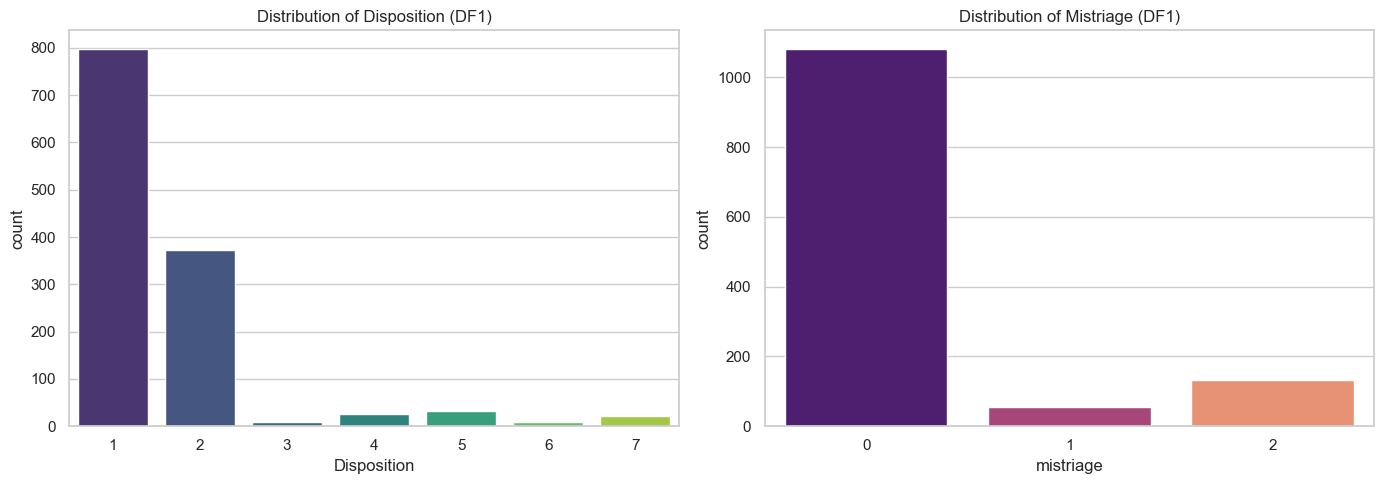

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# 1. Plotting the target variables for Triage: Disposition and Mistriage
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if 'Disposition' in df1.columns:
    sns.countplot(data=df1, x='Disposition', ax=axes[0], palette='viridis')
    axes[0].set_title('Distribution of Disposition (DF1)')

if 'mistriage' in df1.columns:
    sns.countplot(data=df1, x='mistriage', ax=axes[1], palette='magma')
    axes[1].set_title('Distribution of Mistriage (DF1)')

plt.tight_layout()
plt.show()

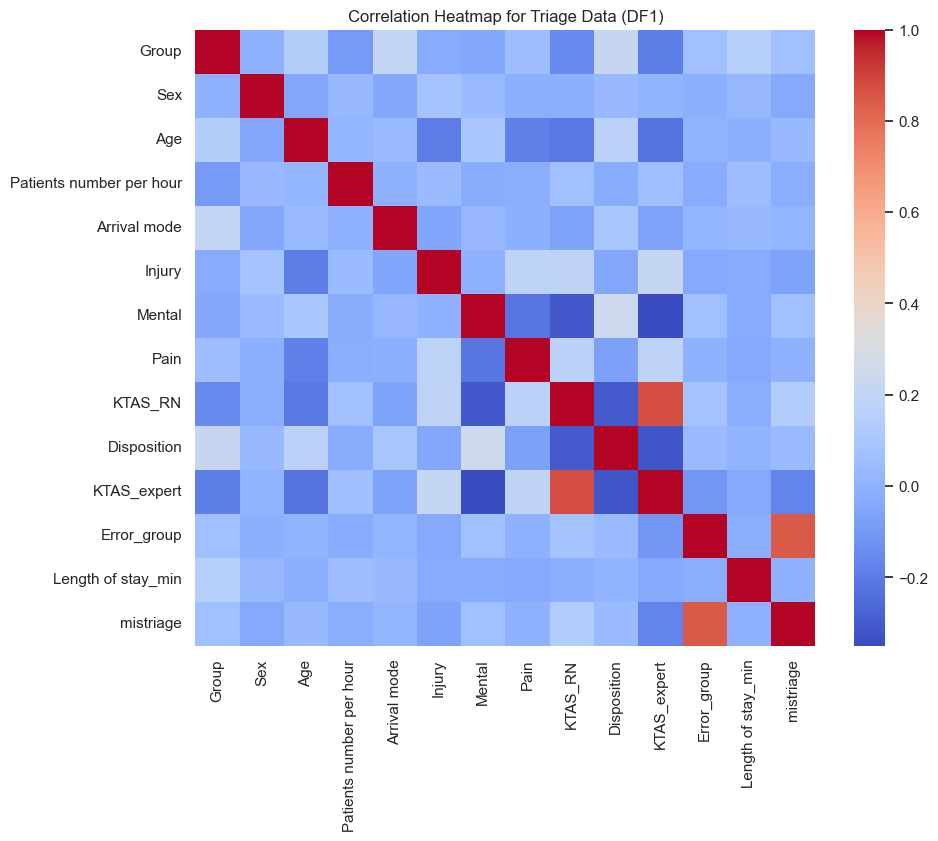

In [10]:
# 2. Correlation heatmap for DF1 (Numeric columns only)
plt.figure(figsize=(10, 8))
numeric_df1 = df1.select_dtypes(include=['float64', 'int64'])
if not numeric_df1.empty:
    corr1 = numeric_df1.corr()
    sns.heatmap(corr1, cmap='coolwarm', annot=False, fmt=".2f")
    plt.title('Correlation Heatmap for Triage Data (DF1)')
    plt.show()

## 2. Deep EDA on DF2 (ICU Mortality Prediction)
Now let's analyze the ICU patient dataset. Important target labels here are `mortality_label` and `sepsis_flag`.

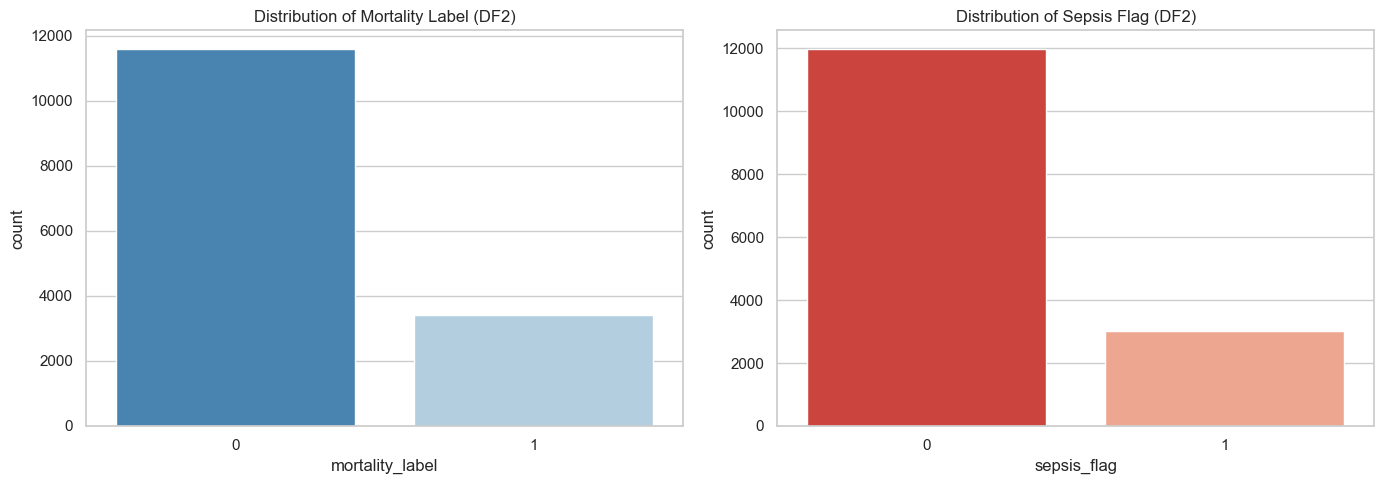

In [11]:
# 1. Plotting target variables for ICU Data
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if 'mortality_label' in df2.columns:
    sns.countplot(data=df2, x='mortality_label', ax=axes[0], palette='Blues_r')
    axes[0].set_title('Distribution of Mortality Label (DF2)')

if 'sepsis_flag' in df2.columns:
    sns.countplot(data=df2, x='sepsis_flag', ax=axes[1], palette='Reds_r')
    axes[1].set_title('Distribution of Sepsis Flag (DF2)')

plt.tight_layout()
plt.show()

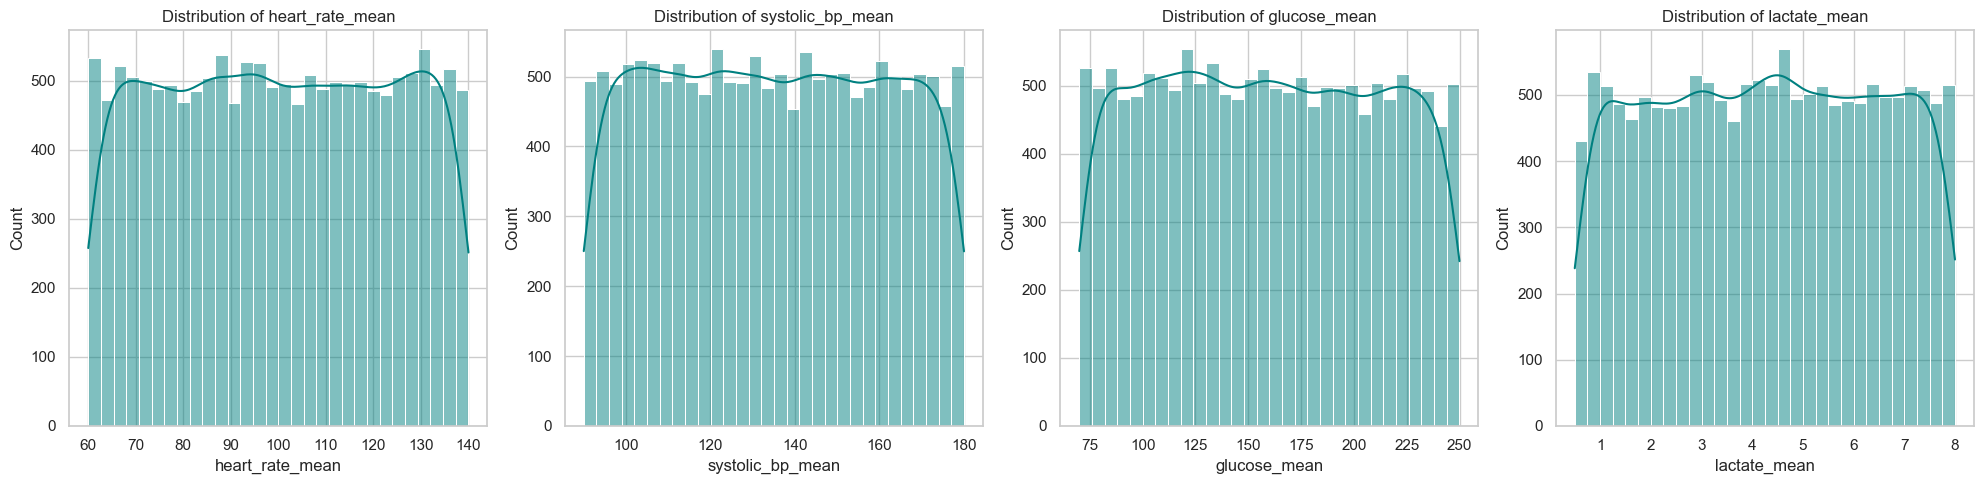

In [12]:
# 2. Distribution of some vital signs
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
cols_to_plot = ['heart_rate_mean', 'systolic_bp_mean', 'glucose_mean', 'lactate_mean']

for i, col in enumerate(cols_to_plot):
    if col in df2.columns:
        sns.histplot(df2[col].dropna(), bins=30, kde=True, ax=axes[i], color='teal')
        axes[i].set_title(f'Distribution of {col}')
        
plt.tight_layout()
plt.show()

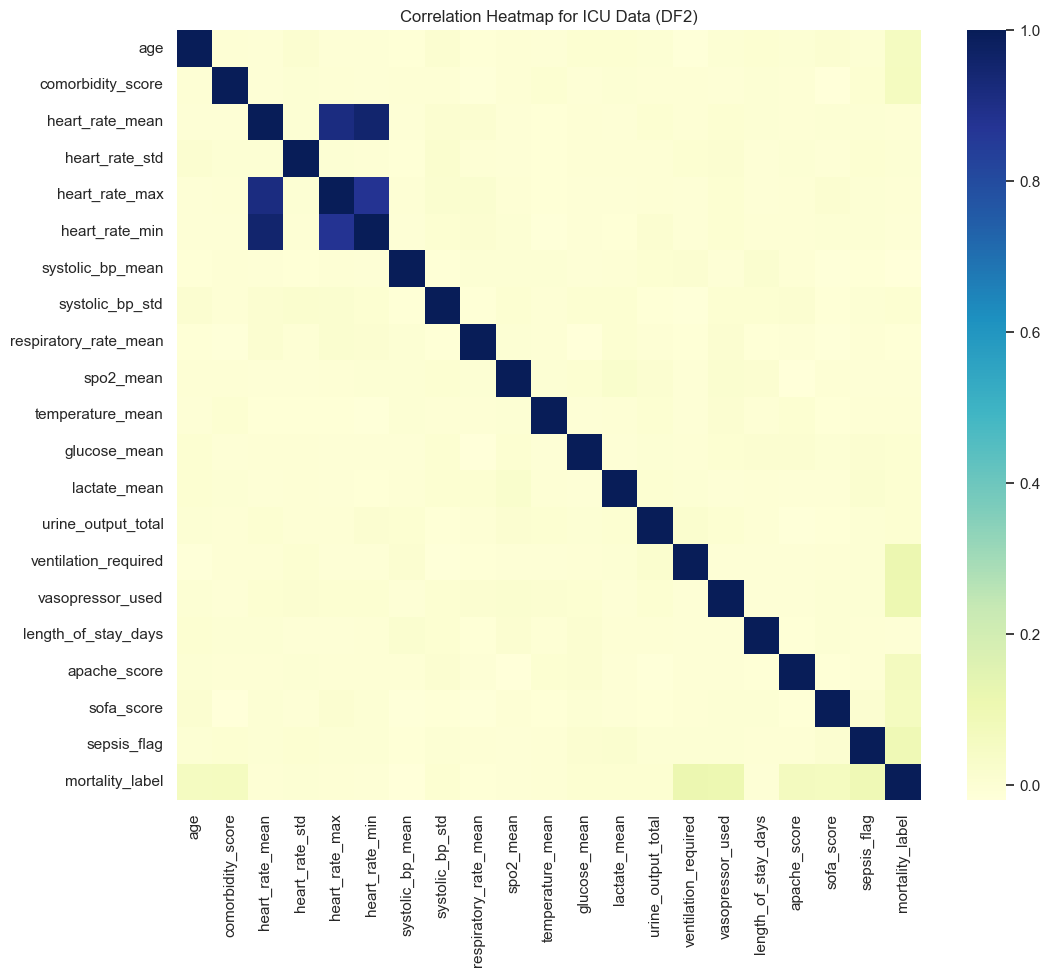

In [13]:
# 3. Correlation heatmap for DF2 (Numeric columns only)
plt.figure(figsize=(12, 10))
numeric_df2 = df2.select_dtypes(include=['float64', 'int64'])
if not numeric_df2.empty:
    corr2 = numeric_df2.corr()
    sns.heatmap(corr2, cmap='YlGnBu', annot=False)
    plt.title('Correlation Heatmap for ICU Data (DF2)')
    plt.show()

### Summary & Decision Framework
- **Option 1: Triage Application (`df1`):** Predicts patient disposition and avoids mistriage in Emergency Services. Great for applications aiming to streamline ER patient intake.
- **Option 2: ICU Patient Monitoring (`df2`):** Predicts patient mortality and sepsis based on vital signs in an ICU context. More focused on critical care outcomes.

Depending on whether your "CareMe" app is focusing on **patient intake (ER)** or **critical condition monitoring (ICU)**, you can select the most appropriate dataset.

# 3. Data Preprocessing & Modeling for CareMe Triage Assistant
Based on the system objectives for real-time triage recommendation and confidence-aware predictions, we will prepare `df1` by:
1. **Selecting Data:** Dropping 'data leakage' columns (events that happen *after* triage like length of stay, discharge disposition, mistriage flags, specific ED diagnosis).
2. **Handling Missing Values & Encoding:** Preparing the vitals and chief complaints for the model.
3. **Training the Model:** Training the RandomForest to predict the true `KTAS_expert` assigned urgency.
4. **Confidence Scoring:** Generating probability vectors alongside predictions.

In [14]:
from sklearn.impute import SimpleImputer

# 1. Define target and drop data leakage columns
target = 'KTAS_expert'

# Columns that are known AFTER triage is done, or are the target itself
leakage_cols = ['Diagnosis in ED', 'Disposition', 'Error_group', 'Length of stay_min', 
                'KTAS duration_min', 'mistriage', 'KTAS_RN', 'Group', 'Patients number per hour']

df_care = df1.drop(columns=[col for col in leakage_cols if col in df1.columns]).copy()

# 2. Separate Features (X) and Target (y)
# Ensure target has no missing values
df_care = df_care.dropna(subset=[target])
y = df_care[target].astype(int) # KTAS scores are typically 1, 2, 3, 4, 5
X = df_care.drop(columns=[target])

# 3. Identify categorical vs numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(exclude=['object']).columns

print("Features used for real-time prediction:\n", list(X.columns))

Features used for real-time prediction:
 ['Sex', 'Age', 'Arrival mode', 'Injury', 'Chief_complain', 'Mental', 'Pain', 'NRS_pain', 'SBP', 'DBP', 'HR', 'RR', 'BT', 'Saturation']


In [15]:
# 4. Preprocessing: Impute missing values and encode categorical features
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Numerical transformer: fill missing with median and scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical transformer: fill missing with mode and one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

X_preprocessed = preprocessor.fit_transform(X)
print("Shape of processed feature matrix:", X_preprocessed.shape)

Shape of processed feature matrix: (1267, 817)


In [16]:
# 5. Train-Test Split and Handle Imbalanced Classes (SMOTE)
X_train, X_test, y_train, y_test = train_split = train_test_split(X_preprocessed, y, test_size=0.2, random_state=42, stratify=y)

# Note: We apply SMOTE *only* to training data to prevent data leakage!
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Original training target distribution:\n", y_train.value_counts())
print("\nResampled training target distribution:\n", y_train_resampled.value_counts())

Original training target distribution:
 KTAS_expert
3    389
4    367
2    176
5     60
1     21
Name: count, dtype: int64

Resampled training target distribution:
 KTAS_expert
4    389
3    389
2    389
1    389
5    389
Name: count, dtype: int64



--- Classification Report ---
              precision    recall  f1-score   support

           1       0.57      0.80      0.67         5
           2       0.59      0.43      0.50        44
           3       0.67      0.83      0.74        98
           4       0.78      0.79      0.78        92
           5       0.00      0.00      0.00        15

    accuracy                           0.70       254
   macro avg       0.52      0.57      0.54       254
weighted avg       0.65      0.70      0.67       254



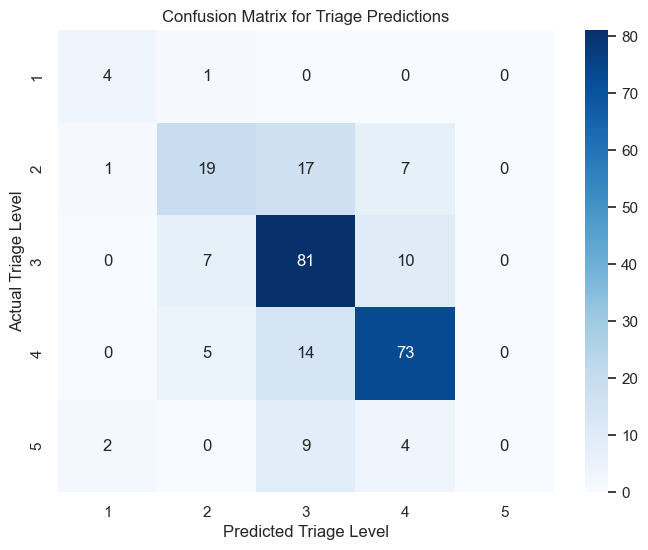

In [17]:
# 6. Train the Model
rf_classifier = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf_classifier.fit(X_train_resampled, y_train_resampled)

# 7. Generate Predictions & Evaluate
y_pred = rf_classifier.predict(X_test)

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Visualizing the Confusion Matrix
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=sorted(y.unique()), yticklabels=sorted(y.unique()))
plt.xlabel('Predicted Triage Level')
plt.ylabel('Actual Triage Level')
plt.title('Confusion Matrix for Triage Predictions')
plt.show()

### Meeting the Objective: Confidence-Aware Predictions
The model should not just spit out a recommendation; it needs to output its **confidence score** so doctors and nurses know when to double-check.
We use `predict_proba()` to see how strongly the model believes in its top choice.

In [18]:
# 8. Confidence-Aware Test Cases
probabilities = rf_classifier.predict_proba(X_test)
predictions = rf_classifier.predict(X_test)

import numpy as np
import pandas as pd

# Let's show the first 5 patients in the test set
confidence_results = []
classes = rf_classifier.classes_

for i in range(5):
    true_label = y_test.iloc[i]
    pred_label = predictions[i]
    # Get the confidence percentage for the chosen prediction
    confidence = np.max(probabilities[i]) * 100
    
    # Get second most likely class (for edge cases)
    sorted_probs = np.argsort(probabilities[i])[::-1]
    second_pred = classes[sorted_probs[1]]
    second_conf = probabilities[i][sorted_probs[1]] * 100
    
    confidence_results.append({
        "True Triage (KTAS)": true_label,
        "Predicted Triage": pred_label,
        "Confidence": f"{confidence:.1f}%",
        "Runner-up Prediction": f"KTAS {second_pred} ({second_conf:.1f}%)",
        "Status": "✅ Correct" if true_label == pred_label else "❌ Incorrect"
    })

results_df = pd.DataFrame(confidence_results)
display(results_df)

print("\nNotice how the model outputs a 'Confidence' percentage. If the confidence is low \n(e.g., under 60%), the web app can trigger an alert saying: \n'⚠️ Borderline Case: Please verify vitals and use clinical judgment.'")

,True Triage (KTAS),Predicted Triage,Confidence,Runner-up Prediction,Status
0,3,3,52.5%,KTAS 4 (31.5%),✅ Correct
1,3,3,47.5%,KTAS 4 (23.5%),✅ Correct
2,3,3,77.5%,KTAS 4 (11.0%),✅ Correct
3,2,2,50.0%,KTAS 3 (36.0%),✅ Correct
4,3,3,61.5%,KTAS 2 (19.5%),✅ Correct



Notice how the model outputs a 'Confidence' percentage. If the confidence is low 
(e.g., under 60%), the web app can trigger an alert saying: 
'⚠️ Borderline Case: Please verify vitals and use clinical judgment.'


### Dedicated Evaluation Metrics
Let's explicitly calculate and visualize the core performance metrics (Accuracy, Precision, Recall, F1-Score) to see exactly how the model performs overall, especially important for clinical applications where we need high precision.

,Metric,Score
0,Accuracy,0.6969
1,Precision (Weighted),0.6537
2,Recall (Weighted),0.6969
3,F1-Score (Weighted),0.6695


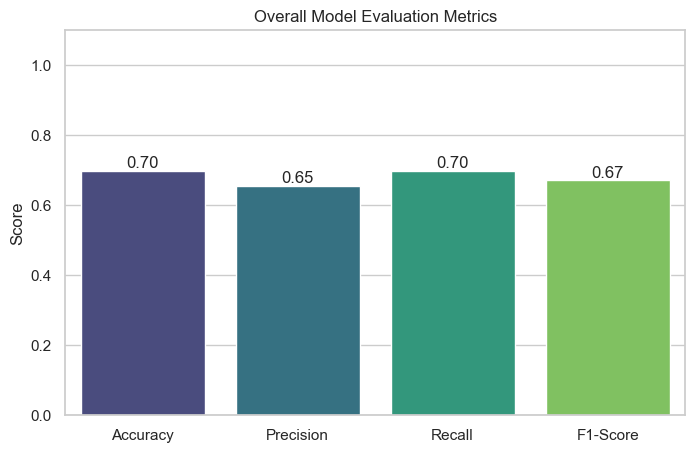

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate metrics (using weighted average due to multi-class imbalance)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Format into a DataFrame for a clean table view
metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision (Weighted)", "Recall (Weighted)", "F1-Score (Weighted)"],
    "Score": [f"{acc:.4f}", f"{prec:.4f}", f"{rec:.4f}", f"{f1:.4f}"]
})

display(metrics_df)

# Visualizing the metrics
plt.figure(figsize=(8, 5))
metrics_values = [acc, prec, rec, f1]
metrics_names = ["Accuracy", "Precision", "Recall", "F1-Score"]

sns.barplot(x=metrics_names, y=metrics_values, palette="viridis")
for i, v in enumerate(metrics_values):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center', fontsize=12)

plt.ylim(0, 1.1)
plt.title("Overall Model Evaluation Metrics")
plt.ylabel("Score")
plt.show()